In [1]:
!pip install pandas_datareader
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from IPython.display import display 

In [4]:
import yfinance as yf

In [5]:
# defining the parameters
ticker_symbol = "PG"
start_date = "1980-01-01"
end_date   = "2024-12-31"
ticker_object = yf.Ticker(ticker_symbol)

# Get the full info dictionary (contains name, exchange, country, etc.)
info = ticker_object.info 

data = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)

# Get the Ticker name for printout
stock_name = info.get('longName', 'N/A')

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

if 'Adj Close' in data.columns:
    prices = data['Adj Close'].dropna()
else:
    prices = data['Close'].dropna()

C:\Users\microsoft\AppData\Local\Temp\ipykernel_13480\969767812.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)


Date
1981-12-31    0.208498
1982-12-31    0.433359
1983-12-31   -0.002385
1984-12-31    0.049947
1985-12-31    0.248821
Freq: YE-DEC, Name: rt.y, dtype: float64

C:\Users\microsoft\AppData\Local\Temp\ipykernel_13480\1699614628.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="1980-01-01")[0]
C:\Users\microsoft\AppData\Local\Temp\ipykernel_13480\1699614628.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="1980-01-01")[0]


Data aligned: 538 monthly observations (1980–2024 period)

MODEL 1: CAPITAL ASSET PRICING MODEL (CAPM) – SUMMARY OUTPUT
                            OLS Regression Results                            
Dep. Variable:           Asset_Excess   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     94.51
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.11e-20
Time:                        17:07:43   Log-Likelihood:                -1645.2
No. Observations:                 538   AIC:                             3294.
Df Residuals:                     536   BIC:                             3303.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------

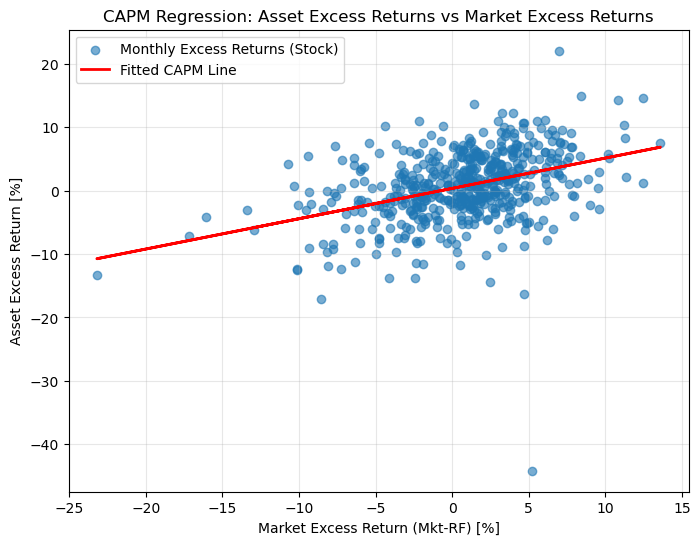


MODEL 2: FAMA-FRENCH 3-FACTOR MODEL – SUMMARY OUTPUT
                            OLS Regression Results                            
Dep. Variable:           Asset_Excess   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     42.70
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           9.60e-25
Time:                        17:07:45   Log-Likelihood:                -1631.1
No. Observations:                 538   AIC:                             3270.
Df Residuals:                     534   BIC:                             3287.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [7]:
# === 1. Download Fama-French Factors and Prepare Data ==================

# Download Fama-French factors (Mkt-RF, SMB, HML) and Risk-Free Rate (RF)
# [0] selects the monthly factors table.
ff_data = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="1980-01-01")[0]
ff_data.index = ff_data.index.to_timestamp() # Convert PeriodIndex to Timestamp Index

# Filter factors to match the asset's period (or your desired period)
ff_data = ff_data.loc[rt_m.index[0]:rt_m.index[-1]] 

# --- Prepare Asset Returns ---
# Multiply by 100 to work in percentages, which is standard for Fama-French data.
asset_returns_pct = rt_m.copy() * 100 
# Ensure asset index is proper Timestamp for alignment
asset_returns_pct.index = asset_returns_pct.index.to_period('M').to_timestamp() 

# Calculate Excess Returns (Asset Return - Risk-Free Rate)
# Note: Fama-French factors (Mkt-RF, SMB, HML) are already in percentage points.
# We use the RF from the Fama-French data.
data_ff = pd.concat([asset_returns_pct, ff_data[["Mkt-RF", "SMB", "HML", "RF"]]], axis=1, join="inner")
data_ff.columns = ["Asset_Excess", "Mkt_RF", "SMB", "HML", "RF"]

# RF is the risk-free rate in percentage, Asset_Excess is the asset return in percentage.
data_ff["Asset_Excess"] = data_ff["Asset_Excess"] - data_ff["RF"] 

print(f"Data aligned: {data_ff.shape[0]} monthly observations (1980–2024 period)")


# ======================================================================
# MODEL 1: CAPM (Market Model)
# ======================================================================

# Dependent Variable (y): Asset Excess Returns
y = data_ff["Asset_Excess"]

# Explanatory Variables (X): Mkt-RF, plus a constant (alpha)
X_capm = sm.add_constant(data_ff["Mkt_RF"])

# Estimation by OLS
capm_model = sm.OLS(y, X_capm).fit()

# Summary of Regression Coefficients (Requirement a)
print("\n" + "="*50)
print("MODEL 1: CAPITAL ASSET PRICING MODEL (CAPM) – SUMMARY OUTPUT")
print("="*50)
print(capm_model.summary())


# Fitted Regression Line Plot (Requirement b)
plt.figure(figsize=(8, 6))
plt.scatter(data_ff["Mkt_RF"], y, alpha=0.6, label="Monthly Excess Returns (Stock)")
plt.plot(data_ff["Mkt_RF"], capm_model.predict(X_capm), color="red", lw=2, label="Fitted CAPM Line")
plt.xlabel("Market Excess Return (Mkt-RF) [%]")
plt.ylabel("Asset Excess Return [%]")
plt.title("CAPM Regression: Asset Excess Returns vs Market Excess Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('CAPM.png', format='png', bbox_inches='tight')
plt.show()
with open("CAPM_summary.html", "w") as f:
    f.write(capm_model.summary().as_html())

# ======================================================================
# MODEL 2: Fama-French 3-Factor Model
# ======================================================================

# Explanatory Variables (X): Mkt-RF, SMB, HML, plus a constant (alpha)
X_ff3 = sm.add_constant(data_ff[["Mkt_RF", "SMB", "HML"]])

# Estimation OLS
ff3_model = sm.OLS(y, X_ff3).fit()

# Summary of Regression Coefficients (Requirement a)
print("\n" + "="*60)
print("MODEL 2: FAMA-FRENCH 3-FACTOR MODEL – SUMMARY OUTPUT")
print("="*60)
print(ff3_model.summary())
with open("FFF_summary.html", "w") as f:
    f.write(capm_model.summary().as_html())